In [49]:
from typing import Annotated, TypedDict
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage

In [50]:
load_dotenv()
llm = ChatGroq(model = 'openai/gpt-oss-120b')

In [51]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [52]:
def chat_node(state: ChatState):
    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })

    if decision["approved"] == "no":
        return {"messages": [AIMessage(content="Not approved.")]}
    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}

In [53]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# checkpointer is required for interrupts
checkpointer = MemorySaver()

app = builder.compile(checkpointer=checkpointer)

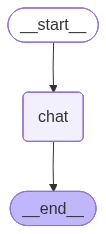

In [54]:
app

In [55]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

result = app.invoke(initial_input, config=config)

In [56]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='3a141ab4-1bb6-418c-b5e3-a999191a36ea')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? yes/no'}, id='044f446ed07480a1224aa6b8f7cfde99')]}

In [57]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [58]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")

In [59]:
final_result = app.invoke(Command(resume={"approved": user_input}), config=config)

In [60]:
print(final_result)

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='3a141ab4-1bb6-418c-b5e3-a999191a36ea'), AIMessage(content='**Gradient descent** is a way for a computer (or a person) to find the lowest point of a bumpy surface—like the bottom of a valley—by taking a series of small steps downhill.\n\nHere’s a super‑simple picture:\n\n| Step | What happens | Why it helps |\n|------|--------------|--------------|\n| 1️⃣  | **Start somewhere** (any random spot on the hill). | You need a starting point; you don’t know where the bottom is yet. |\n| 2️⃣  | **Look at the slope** at that spot. | The slope tells you which direction is “downhill” and how steep it is. |\n| 3️⃣  | **Take a step** a little bit in the downhill direction. The step size is called the **learning rate**. | Moving downhill lowers your “height” (the value you’re trying to minimize). |\n| 4️⃣  | **Repeat**: check the new slope, step again, and keep going. 